In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import networkx as nx
import planarity
import itertools
import random
import math
random.seed(2023)
import numpy as np
np.random.seed(2023)
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
colors = ['#104680','#317CB7','#6DADD1','#B6D7E8','#E9F1F4','#FBE3D5','#F6B293','#DC6D57','#B72230','#6D011F']
cmap = ListedColormap(colors)
%matplotlib inline

# <b><span style='color:#F1C40F'>|</span>一、构建金融风险溢出网络 </b>
## （一）构建网络

In [3]:
# 读取网络数据
file_path = '../data/net_spoillover_data.xlsx'  
data = pd.read_excel(file_path, index_col=0)

# 构建带权有向网络
G = nx.DiGraph()

# 添加边及权重
for source in data.index:
    for target in data.columns:
        weight = data.loc[source, target]
        if weight > 0:  # 仅在权重大于 0 时添加边
            G.add_edge(source, target, weight=weight)

# 输出每个节点的标签
labels = list(G.nodes)
print("节点标签:", labels)

节点标签: ['CMB', 'CSC', 'ECP', 'DFC', 'XYR', 'HCX', 'NJB', 'GYS', 'SXZ', 'XLF', 'SPDB', 'YTG', 'PING', 'HDS', 'COC', 'CIB', 'JDI', 'NBB', 'SGXA', 'YXC', 'XCF', 'CITICS', 'HXG', 'SWZ', 'BOCOM', 'ABC', 'PAB', 'JYT', 'ZDO', 'CLC', 'AJG', 'GFS', 'CYS', 'GJS', 'GHS', 'MWC', 'HJC', 'HXB', 'JLG', 'DBS', 'CMBC', 'XGD', 'GIC', 'BJB', 'TPAC']


## （二）过滤网络特征
- 平面极大过滤图(Planar Maximally Filtered Garph)
- PMFG的特点是保持图的平面性，即可以在平面上绘制而不出现边的交叉。这种图保留了最小生成树（MST）和更多有意义的边，因此能够提供比MST更丰富的结构信息。PMFG在具有n个节点时包含最多3(n−2)条边，提供比只包含n−1条边的MST更为详细的网络特征。

In [4]:
import pandas as pd
import networkx as nx

# PMFG减边算法
def get_network_pmfg(G):
    # 确保图的节点数大于等于3
    if G.number_of_nodes() < 3:
        print("图的节点数必须至少为3个。")
        return None
    
    sorted_edges = []
    for source, dest, data in G.edges(data=True):
        sorted_edges.append({'source': source, 'dest': dest, 'weight': abs(data.get('weight', 1))})
    
    # 按照权重排序边
    sorted_edges.sort(key=lambda x: x['weight'], reverse=True)
    
    pmfg = nx.Graph()  # 创建无向图
    
    for edge in sorted_edges:
        pmfg.add_edge(edge['source'], edge['dest'], weight=edge['weight'])
        
        # 检查平面性，若不平面则移除边
        if not check_planarity(pmfg):
            pmfg.remove_edge(edge['source'], edge['dest'])
        
        # 满足6*(节点数-2)边的条件，停止添加边
        if pmfg.number_of_edges() >= 6 * (G.number_of_nodes() - 2):
            break
    
    return pmfg

# 使用networkx检查图的平面性
def check_planarity(G):
    is_planar, _ = nx.check_planarity(G)
    return is_planar

pmfg = get_network_pmfg(G)

if pmfg:
    # 移除自环
    pmfg.remove_edges_from(nx.selfloop_edges(pmfg))

    # 输出 PMFG 的边
    print("pmfg 的边：")
    for edge in pmfg.edges(data=True):
        print(edge)

    # 指定保存路径
    output_path = "../result/pmfg"  # 输出路径，确保该路径存在

    # 保存为 GEXF 格式
    nx.write_gexf(pmfg, f"{output_path}.gexf")
    print(f"网络已保存为 GEXF 文件: {output_path}.gexf")

    # 保存为 Edgelist 格式
    nx.write_edgelist(pmfg, f"{output_path}.edgelist")
    print(f"网络已保存为 Edgelist 文件: {output_path}.edgelist")


pmfg 的边：
('JYT', 'AJG', {'weight': 0.49})
('JYT', 'SXZ', {'weight': 0.17})
('JYT', 'HXG', {'weight': 0.22})
('JLG', 'SWZ', {'weight': 0.06})
('JLG', 'SXZ', {'weight': 0.08})
('JLG', 'CSC', {'weight': 0.06})
('JDI', 'CLC', {'weight': 1.66})
('JDI', 'HJC', {'weight': 1.3})
('JDI', 'XYR', {'weight': 0.97})
('HCX', 'SXZ', {'weight': 0.27})
('HCX', 'TPAC', {'weight': 0.26})
('HCX', 'GJS', {'weight': 0.22})
('HDS', 'XYR', {'weight': 1.2})
('HDS', 'SXZ', {'weight': 0.8})
('HDS', 'AJG', {'weight': 0.95})
('PING', 'ABC', {'weight': 0.01})
('PING', 'BOCOM', {'weight': 0.21})
('PING', 'NBB', {'weight': 0.08})
('XGD', 'HXG', {'weight': 0.62})
('XGD', 'SXZ', {'weight': 0.41})
('XGD', 'YXC', {'weight': 0.17})
('XLF', 'CSC', {'weight': 0.95})
('XLF', 'SXZ', {'weight': 0.98})
('XLF', 'GFS', {'weight': 0.8})
('ECP', 'GYS', {'weight': 1.01})
('ECP', 'SXZ', {'weight': 1.07})
('ECP', 'GIC', {'weight': 0.57})
('DFC', 'CITICS', {'weight': 0.97})
('DFC', 'XYR', {'weight': 0.57})
('DFC', 'HXG', {'weight': 1.0

In [5]:
def build_pmfg(graph):
    """
    构建平面最大过滤图（PMFG）。
    :param graph: 输入有向加权图（DiGraph）
    :return: 带权有向 PMFG 图
    """
    # 将有向图转为无向图（只保留较大的边权）
    undirected_graph = nx.Graph()
    for u, v, d in graph.edges(data=True):
        weight = d['weight']
        if undirected_graph.has_edge(u, v):
            # 如果已经有这条边，保留权重更大的那条边
            if undirected_graph[u][v]['weight'] < weight:
                undirected_graph[u][v]['weight'] = weight
        else:
            undirected_graph.add_edge(u, v, weight=weight)

    # 按权重从大到小排序边
    edges_sorted = sorted(undirected_graph.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)

    # 构建无向 PMFG
    pmfg_undirected = nx.Graph()
    pmfg_undirected.add_nodes_from(undirected_graph.nodes(data=True))

    for u, v, d in edges_sorted:
        pmfg_undirected.add_edge(u, v, weight=d['weight'])
        if not nx.check_planarity(pmfg_undirected)[0]:  # 检查是否仍然是平面图
            pmfg_undirected.remove_edge(u, v)  # 如果不是平面图，移除该边

    # 将无向 PMFG 转回有向图（保持原始方向和权重）
    pmfg = nx.DiGraph()
    pmfg.add_nodes_from(pmfg_undirected.nodes(data=True))
    for u, v in pmfg_undirected.edges():
        if graph.has_edge(u, v) and graph[u][v]['weight'] == pmfg_undirected[u][v]['weight']:
            pmfg.add_edge(u, v, weight=pmfg_undirected[u][v]['weight'])
        elif graph.has_edge(v, u) and graph[v][u]['weight'] == pmfg_undirected[u][v]['weight']:
            pmfg.add_edge(v, u, weight=pmfg_undirected[u][v]['weight'])

    return pmfg

# 加载数据
file_path = '../data/net_spoillover_data.xlsx'  
data = pd.read_excel(file_path, index_col=0)

# 构建有向图
G = nx.DiGraph()
for source in data.index:
    for target in data.columns:
        weight = data.loc[source, target]
        if weight > 0:  # 仅在权重大于 0 时添加边
            G.add_edge(source, target, weight=weight)

# 构建 PMFG
pmfg = build_pmfg(G)
# 移除自环
pmfg.remove_edges_from(nx.selfloop_edges(pmfg))

# 输出 PMFG 的边
print("PMFG 的边：")
for edge in pmfg.edges(data=True):
    print(edge)

# 指定保存路径
output_path = "../result/pmfg_directed"

# 保存为 GEXF 格式
nx.write_gexf(pmfg, f"{output_path}.gexf")
print(f"网络已保存为 GEXF 文件: {output_path}.gexf")

# 保存为 Edgelist 格式
nx.write_edgelist(pmfg, f"{output_path}.edgelist")
print(f"网络已保存为 Edgelist 文件: {output_path}.edgelist")

PMFG 的边：
('CMB', 'BOCOM', {'weight': 7.63})
('CMB', 'PAB', {'weight': 5.26})
('CMB', 'CMBC', {'weight': 5.08})
('CMB', 'SPDB', {'weight': 5.03})
('CSC', 'CITICS', {'weight': 8.23})
('CSC', 'SXZ', {'weight': 6.68})
('ECP', 'SXZ', {'weight': 2.24})
('ECP', 'GIC', {'weight': 1.16})
('DFC', 'CITICS', {'weight': 3.19})
('DFC', 'XYR', {'weight': 2.77})
('DFC', 'HXG', {'weight': 1.89})
('XYR', 'YTG', {'weight': 4.12})
('XYR', 'SXZ', {'weight': 4.1})
('XYR', 'CITICS', {'weight': 2.98})
('HCX', 'SXZ', {'weight': 1.95})
('HCX', 'TPAC', {'weight': 1.68})
('HCX', 'GJS', {'weight': 0.89})
('NJB', 'NBB', {'weight': 5.52})
('NJB', 'BJB', {'weight': 5.07})
('NJB', 'SXZ', {'weight': 4.76})
('NJB', 'BOCOM', {'weight': 4.08})
('NJB', 'CITICS', {'weight': 3.15})
('GYS', 'ECP', {'weight': 2.97})
('GYS', 'SXZ', {'weight': 6.98})
('GYS', 'CITICS', {'weight': 6.0})
('GYS', 'GIC', {'weight': 2.83})
('XLF', 'CSC', {'weight': 2.69})
('XLF', 'SXZ', {'weight': 2.28})
('XLF', 'GFS', {'weight': 1.53})
('SPDB', 'BOCO

In [ ]:
edges_data = []
for edge in pmfg.edges(data=True):
    source, target, attrs = edge
    weight = attrs.get('weight', 0)  # 如果没有权重，默认设为0
    edges_data.append([source, target, weight])

# 将边信息转换为DataFrame
df = pd.DataFrame(edges_data, columns=['Source', 'Target', 'Weight'])

csv_file_path = "../result/static_pmfg_network.csv"

# 保存为csv文件
df.to_csv(csv_file_path, index=False)
print(f"网络已保存为CSV文件: {csv_file_path}")

网络已保存为CSV文件: ../result/static_pmfg_network.csv


In [9]:
adj_matrix = nx.to_pandas_adjacency(pmfg)

# 保存为CSV
adj_matrix.to_csv('../result/network_matrix.csv')

In [7]:
# 查看网络基本信息
print("节点数:", pmfg.number_of_nodes())
print("边数:", pmfg.number_of_edges())
print("平均度:", sum(dict(pmfg.degree()).values()) / pmfg.number_of_nodes())
print("图的密度:", nx.density(pmfg))
clustering_coefficient = nx.clustering(pmfg)
print("节点局部聚类系数:", clustering_coefficient)
# 计算有向图的全局聚类系数
global_clustering_coefficient = nx.transitivity(pmfg)
print("全局聚类系数:", global_clustering_coefficient)

节点数: 45
边数: 129
平均度: 5.733333333333333
图的密度: 0.06515151515151515
节点局部聚类系数: {'CMB': 0.4166666666666667, 'CSC': 0.3, 'ECP': 0.5, 'DFC': 0.5, 'XYR': 0.13186813186813187, 'HCX': 0.5, 'NJB': 0.3, 'GYS': 0.35, 'SXZ': 0.0665024630541872, 'XLF': 0.5, 'SPDB': 0.4166666666666667, 'YTG': 0.19444444444444445, 'PING': 0.5, 'HDS': 0.5, 'COC': 0.3333333333333333, 'CIB': 0.5, 'JDI': 0.5, 'NBB': 0.2619047619047619, 'SGXA': 0.5, 'YXC': 0.35, 'XCF': 0.5, 'CITICS': 0.1023391812865497, 'HXG': 0.23214285714285715, 'SWZ': 0.35, 'BOCOM': 0.17272727272727273, 'ABC': 0.2619047619047619, 'PAB': 0.4166666666666667, 'JYT': 0.5, 'ZDO': 0.5, 'CLC': 0.26666666666666666, 'AJG': 0.35, 'GFS': 0.35, 'CYS': 0.4166666666666667, 'GJS': 0.35, 'GHS': 0.4166666666666667, 'MWC': 0.3, 'HJC': 0.35, 'HXB': 0.4166666666666667, 'JLG': 0.5, 'DBS': 0.5, 'CMBC': 0.2619047619047619, 'XGD': 0.5, 'GIC': 0.35, 'BJB': 0.3, 'TPAC': 0.35}
全局聚类系数: 0.4246575342465753


In [8]:
# 确认pmfg网络是否成功转换为有向网络
isinstance(pmfg, nx.DiGraph)

True

# <b><span style='color:#F1C40F'>|</span>二、网络拓扑结构（宏观视角）</b>
### 1、节点度与度分布

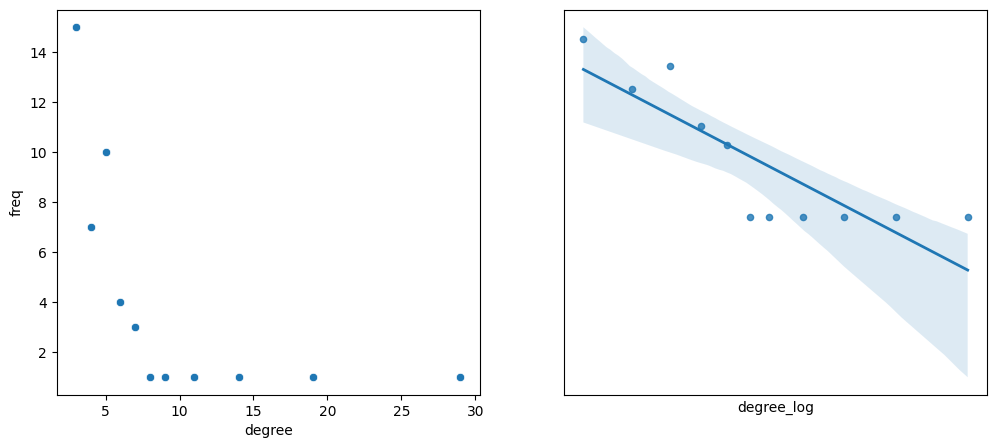

In [9]:
fig, axes = plt.subplots(figsize=(12, 5), nrows=1, ncols=2)
degree_freq = nx.degree_histogram(pmfg)
degrees = range(len(degree_freq))
df_degree = pd.DataFrame({'degree': degrees, 'freq': degree_freq})
df_degree = df_degree[df_degree['freq']>0]

df_degree['degree_log'] = np.log(df_degree['degree'])
df_degree['freq_log'] = np.log(df_degree['freq'])
g = sns.scatterplot(x='degree', y='freq', data=df_degree,ax=axes[0])
#axes[0].set(xlim=(-50, None))
axes[0].label_outer()

#axes[1].set(xscale="log", yscale="log")
g_log = sns.regplot(x='degree_log', y='freq_log', data=df_degree, line_kws={"linewidth":2}, scatter_kws={'s':20})
axes[1].axes.xaxis.set_ticks([])
axes[1].axes.yaxis.set_ticks([])
axes[1].label_outer()

plt.show()

### 2、平均路径长度

In [10]:
nx.is_strongly_connected(pmfg)
# print(f"网络平均距离为： {nx.average_shortest_path_length(pmfg):.4f}")

False

### 3、聚类系数

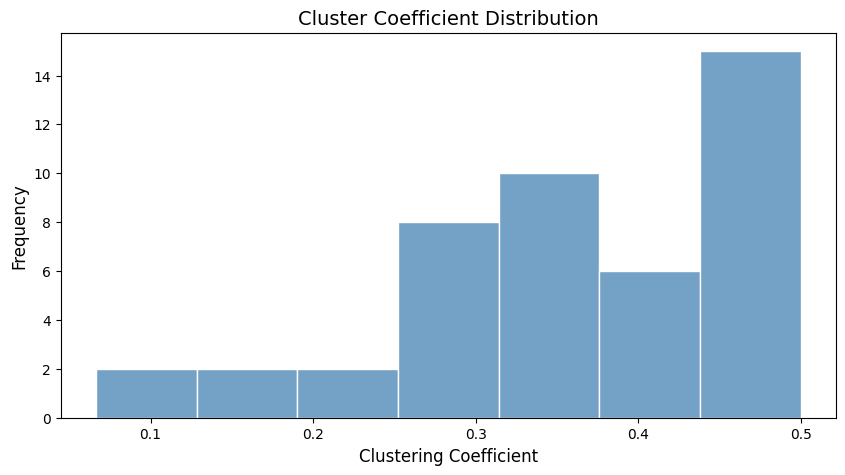

In [11]:
# 计算聚类系数
cluster = nx.clustering(pmfg)

# 绘制直方图
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    list(cluster.values()),
    color="steelblue",  
    edgecolor="white",  
)

# 设置标题和坐标轴标签
ax.set_title("Cluster Coefficient Distribution", fontsize=14)
ax.set_xlabel("Clustering Coefficient", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)

# 显示图表
plt.show()

In [12]:
#平均集聚系数
print(f"网络平均集聚系数为： {nx.average_clustering(pmfg):.4f}")

网络平均集聚系数为： 0.3697


### 4、连通性

In [13]:
strongly_connected_components = list(nx.strongly_connected_components(pmfg))

# 取出最大的强连通分量
largest_component = max(strongly_connected_components, key=len)
subgraph = pmfg.subgraph(largest_component)

# 计算子图的平均最短路径
average_length = nx.average_shortest_path_length(subgraph)
print(f"网络最大强连通子图的平均最短路径为：{average_length:.8f}")

网络最大强连通子图的平均最短路径为：1.50000000


### 5、同配性
- 网络同配系数（assortativity coefficient）用于衡量网络中节点的连接偏好，是描述网络结构的一个重要指标。它表示网络中具有相似度的节点（例如，具有相同或相近度值的节点）倾向于互相连接的程度。
- 正的同配系数（大于 0）：表示网络是同配的，也就是说，度大的节点倾向于与度大的节点相连，而度小的节点倾向于与度小的节点相连。
- 负的同配系数（小于 0）：表示网络是异配的，即度大的节点更倾向于与度小的节点相连。这种结构通常在金融网络、互联网等系统中出现，表明关键节点与外围节点有更多连接。
- 接近 0 的同配系数：表示网络是无同配性的，连接是随机的。

In [14]:
degree1 = []
degree2 = []

for v in pmfg:  
    for neighbor in pmfg.neighbors(v):
        degree1.append(pmfg.degree(v))
        degree2.append(pmfg.degree(neighbor))

data = pd.DataFrame({'degree1': degree1, 
                     'degree2': degree2})

print(f"网络同配系数为： {nx.degree_assortativity_coefficient(pmfg):.4f}")

网络同配系数为： -0.1547


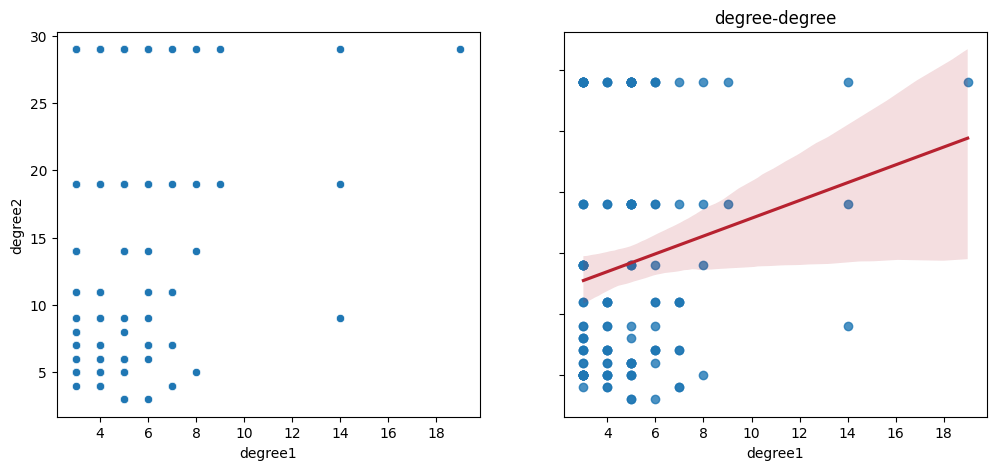

In [15]:
fig, axes = plt.subplots(figsize=(12, 5), nrows=1, ncols=2)

g = sns.scatterplot(x='degree1', y='degree2', data=data,ax=axes[0])
axes[0].label_outer()

g_reg = sns.regplot(x='degree1', y='degree2', data=data,ax=axes[1],line_kws={'color':'#B72230'})
axes[1].label_outer()

plt.title('degree-degree')
plt.show()

### 6、加权平均度
- 加权平均出度：通过计算每个节点出边的权重之和，取所有节点的平均值。
- 加权平均入度：通过计算每个节点入边的权重之和，取所有节点的平均值。

In [16]:
# 计算加权平均出度
def weighted_out_degree(G):
    total_out_degree = 0
    for node in G.nodes:
        # 计算节点的加权出度
        out_degree = sum([G[node][neighbor]['weight'] for neighbor in G.neighbors(node)])
        print(f"Node {node} has weighted out-degree: {out_degree}")  # 打印出度
        total_out_degree += out_degree
    return total_out_degree / len(G.nodes)

# 计算加权平均入度
def weighted_in_degree(G):
    total_in_degree = 0
    for node in G.nodes:
        # 计算节点的加权入度
        in_degree = sum([G[neighbor][node]['weight'] for neighbor in G.predecessors(node)])
        print(f"Node {node} has weighted in-degree: {in_degree}")  # 打印入度
        total_in_degree += in_degree
    return total_in_degree / len(G.nodes)

# 计算加权平均出度和加权平均入度
avg_out_degree = weighted_out_degree(pmfg)
avg_in_degree = weighted_in_degree(pmfg)

print(f"加权平均出度: {avg_out_degree}")
print(f"加权平均入度: {avg_in_degree}")

Node CMB has weighted out-degree: 23.0
Node CSC has weighted out-degree: 14.91
Node ECP has weighted out-degree: 3.4000000000000004
Node DFC has weighted out-degree: 7.85
Node XYR has weighted out-degree: 11.2
Node HCX has weighted out-degree: 4.52
Node NJB has weighted out-degree: 22.58
Node GYS has weighted out-degree: 18.78
Node SXZ has weighted out-degree: 0
Node XLF has weighted out-degree: 6.5
Node SPDB has weighted out-degree: 11.52
Node YTG has weighted out-degree: 8.370000000000001
Node PING has weighted out-degree: 10.93
Node HDS has weighted out-degree: 6.539999999999999
Node COC has weighted out-degree: 16.61
Node CIB has weighted out-degree: 13.989999999999998
Node JDI has weighted out-degree: 1.27
Node NBB has weighted out-degree: 18.419999999999998
Node SGXA has weighted out-degree: 13.84
Node YXC has weighted out-degree: 12.95
Node XCF has weighted out-degree: 9.37
Node CITICS has weighted out-degree: 6.7
Node HXG has weighted out-degree: 17.54
Node SWZ has weighted out

# <b><span style='color:#F1C40F'>|</span>三、网络社群识别（中观视角）</b>
## （一）社群划分方法
<div style="color:white;display:fill;border-radius:8px;
            background-color:#d3d3d3;font-size:150%;
            font-family:Nexa;letter-spacing:0.5px">
    <p style="padding: 8px;color:white;"><b>1.Louvain算法</b></p>
</div>

In [17]:
import community as community_louvain
import networkx as nx
import matplotlib.pyplot as plt

# 将有向图转换为无向图
undirected_pmfg = pmfg.to_undirected()

# 使用 Louvain 算法进行社群划分
partition = community_louvain.best_partition(undirected_pmfg)

# 输出社群划分结果
print("社群划分结果：")
print(partition)

社群划分结果：
{'CMB': 0, 'CSC': 1, 'ECP': 1, 'DFC': 2, 'XYR': 2, 'HCX': 1, 'NJB': 0, 'GYS': 1, 'SXZ': 1, 'XLF': 1, 'SPDB': 0, 'YTG': 2, 'PING': 0, 'HDS': 2, 'COC': 2, 'CIB': 0, 'JDI': 2, 'NBB': 0, 'SGXA': 2, 'YXC': 0, 'XCF': 2, 'CITICS': 1, 'HXG': 2, 'SWZ': 1, 'BOCOM': 0, 'ABC': 0, 'PAB': 0, 'JYT': 2, 'ZDO': 2, 'CLC': 2, 'AJG': 2, 'GFS': 1, 'CYS': 1, 'GJS': 1, 'GHS': 1, 'MWC': 2, 'HJC': 2, 'HXB': 0, 'JLG': 1, 'DBS': 1, 'CMBC': 0, 'XGD': 2, 'GIC': 1, 'BJB': 0, 'TPAC': 1}


<div style="color:white;display:fill;border-radius:8px;
            background-color:#d3d3d3;font-size:150%;
            font-family:Nexa;letter-spacing:0.5px">
    <p style="padding: 8px;color:white;"><b>2.Girvan-Newman算法</b></p>
</div>

In [18]:
import networkx as nx
from networkx.algorithms.community import girvan_newman
import matplotlib.pyplot as plt

communities = girvan_newman(pmfg)

# 获取第一个划分结果
first_level_communities = next(communities)
community_list = [list(c) for c in first_level_communities]

# 打印社区划分结果
for i, community in enumerate(community_list):
    print(f"Community {i+1}: {community}")

Community 1: ['PAB', 'CMBC', 'PING', 'CMB', 'CIB', 'NJB', 'BOCOM', 'ABC', 'HXB', 'NBB', 'SPDB', 'BJB']
Community 2: ['JYT', 'YTG', 'ECP', 'MWC', 'CLC', 'XLF', 'CSC', 'SWZ', 'HDS', 'AJG', 'GYS', 'HXG', 'CYS', 'YXC', 'HJC', 'DFC', 'XGD', 'SXZ', 'GFS', 'COC', 'JLG', 'XYR', 'GIC', 'XCF', 'GJS', 'DBS', 'ZDO', 'TPAC', 'SGXA', 'HCX', 'JDI', 'CITICS', 'GHS']


<div style="color:white;display:fill;border-radius:8px;
            background-color:#d3d3d3;font-size:150%;
            font-family:Nexa;letter-spacing:0.5px">
    <p style="padding: 8px;color:white;"><b>3.Infomap算法</b></p>
</div>

In [19]:
import networkx as nx
import pandas as pd
from infomap import Infomap
import matplotlib.pyplot as plt
from matplotlib import cm

# 创建节点名称到整数 ID 的映射
node_to_id = {node: i for i, node in enumerate(pmfg.nodes())}
id_to_node = {i: node for node, i in node_to_id.items()}

# 使用 Infomap 进行社群划分
im = Infomap()

# 将 PMFG 的边添加到 Infomap 模型
for u, v, data in pmfg.edges(data=True):
    weight = data['weight']
    im.add_link(node_to_id[u], node_to_id[v], weight)

# 运行 Infomap 算法
im.run()

# 提取社群划分结果并按社群分组
community_groups = {}
for node in im.nodes:
    community = node.module_id  # 获取社群编号
    original_node = id_to_node[node.node_id]  # 还原原始节点名称
    if community not in community_groups:
        community_groups[community] = []
    community_groups[community].append(original_node)

# 按格式输出社群划分结果
print("社群划分结果：")
for community, nodes in community_groups.items():
    print(f"属于社群 {community} 的节点有：{', '.join(map(str, nodes))}")

社群划分结果：=======================================================
  Infomap v2.8.0 starts at 
属于社群 1 的节点有：SXZ, CITICS, CSC, SWZ, GFS, TPAC, GYS, GJS, GHS, CYS, GIC, DBS, XLF, ECP, HCX, JLG
属于社群 2 的节点有：BOCOM, ABC, CMBC, NBB, BJB, NJB, HXB, CMB, SPDB, PAB, CIB, PING
属于社群 3 的节点有：XYR, YTG, MWC, CLC, COC, HJC, SGXA, ZDO, XCF, HDS, JDI
属于社群 4 的节点有：HXG, YXC, AJG, DFC, XGD, JYT
2025-11-14 19:41:12
  -> Input network: 
  -> No file output!
  -> Ordinary network input, using the Map Equation for first order network flows
Calculating global network flow using flow model 'undirected'... 
  -> Using undirected links.
  => Sum node flow: 1, sum link flow: 1
Build internal network with 45 nodes and 129 links...
  -> One-level codelength: 5.02337372

Trial 1/1 starting at 2025-11-14 19:41:12
Two-level compression: 14% 0.096% 
Partitioned to codelength 0.350732517 + 3.9590066 = 4.30973912 in 4 modules.
Super-level compression: to codelength 4.30973912 in 4 top modules.

Recursive sub-structure compression

In [8]:
# 2. 定义金融机构的分类标签
categories = {
    "券商": [
        "HJC", "SGXA", "HDS", "COC", "DBS", "JLG", "GYS", "GHS", "GFS", 
        "CYS", "ECP", "YXC", "CLC", "SXZ", "DFC", "XGD", "CITICS", "JDI", 
        "GIC", "XCF", "GJS", "ZDO", "HCX", "XLF", "SWZ", "MWC", "HXG", 
        "AJG", "XYR", "YTG", "CSC"
    ],
    "银行": [
        "PAB", "NBB", "SPDB", "HXB", "CMBC", "CITICS", "CMB", "JDI", 
        "CIB", "BJB", "ABC", "PING", "BOCOM","NJB"
    ],
    "保险": [
        "JYT", "TPAC", "PING"
    ]
}


# 3. 创建分类标签映射表
node_labels = {}
for category, institutions in categories.items():
    for institution in institutions:
        node_labels[institution] = category

# 4. 给网络节点添加分类标签
for node in pmfg.nodes():
    category = node_labels.get(node, "未分类")  # 如果节点未出现在对照表中，标记为"未分类"
    pmfg.nodes[node]["category"] = category

# 5. 保存为 Gephi 支持的 .gexf 文件
output_file = "../result/pmfg_with_labels.gexf"
nx.write_gexf(pmfg, output_file)
print(f"PMFG网络已保存为 {output_file}，可在Gephi中加载。")

PMFG网络已保存为 ../result/pmfg_with_labels.gexf，可在Gephi中加载。


In [29]:
infomap_communities = {
    'SXZ': 1, 'CITICS': 1, 'CSC': 1, 'SWZ': 1, 'GFS': 1, 'TPAC': 1, 'GYS': 1, 'GJS': 1, 
    'GHS': 1, 'CYS': 1, 'GIC': 1, 'DBS': 1, 'XLF': 1, 'ECP': 1, 'HCX': 1, 'JLG': 1,
    'BOCOM': 0, 'ABC': 0, 'CMBC': 0, 'NBB': 0, 'BJB': 0, 'NJB': 0, 'HXB': 0, 'CMB': 0, 
    'SPDB': 0, 'PAB': 0, 'CIB': 0, 'PING': 0,
    'XYR': 2, 'YTG': 2, 'MWC': 2, 'CLC': 2, 'COC': 2, 'HJC': 2, 'SGXA': 2, 'ZDO': 2, 
    'XCF': 2, 'HDS': 2, 'JDI': 2,
    'HXG': 3, 'YXC': 3, 'AJG': 3, 'DFC': 3, 'XGD': 3, 'JYT': 3
}
file_path = '../data/金融机构对照.xlsx'

financial_mapping = pd.read_excel(file_path, header=0)
financial_mapping['Community'] = financial_mapping['英文缩写'].map(infomap_communities)

financial_mapping["英文缩写"] = financial_mapping["英文缩写"].str.strip()  # 去掉多余的空格
financial_mapping["英文缩写"] = financial_mapping["英文缩写"].str.upper()  # 转换为大写

financial_mapping['Community'] = financial_mapping['英文缩写'].map(infomap_communities)

unmatched_codes = financial_mapping[financial_mapping['Community'].isna()]
print("未匹配的节点：", unmatched_codes)

output_file = '../result/infomap_communities.xlsx'
financial_mapping.to_excel(output_file, index=False)

未匹配的节点： Empty DataFrame
Columns: [中文名称, 英文缩写, 分类, Community]
Index: []


## （二）社群划分效果评估指标
- **模块度（Modularity）**：模块度是用于评估社群划分质量的最常用指标。它衡量社群内的连接密度与随机网络中相同划分下的连接密度的差异。范围从 -1 到 1，一般来说，模块度大于 0 表示比随机情况更清晰的社区结构。接近 1 的值表明清晰的社区结构。
- **内聚度和离散度（Cohesiveness and Separation）**：内聚度评估社群内部节点之间的紧密程度；离散度衡量社群与其他社群的分离程度。高离散度表示不同社群间连接较少，边界清晰。这两者结合用于判断社群是否在内部高度互联并与其他社群分离。
- **Conductance（导电性）**：衡量社群边缘的质量，计算社群边缘与其他社群的连通情况，值越小越好，表示社群与其他社群的连通越少。适用于评估社群划分的边界清晰度。

In [30]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from networkx.algorithms.community import modularity
from itertools import combinations
import numpy as np

In [31]:
#模块度和 Conductance
def calculate_modularity(graph, communities):
    """计算模块度"""
    return modularity(graph, communities)

def calculate_conductance(graph, communities):
    """计算Conductance"""
    def single_conductance(graph, community):
        """计算单个社区的Conductance"""
        boundary_edges = nx.edge_boundary(graph, community)
        internal_edges = len(list(boundary_edges))
        cut_edges = sum(1 for edge in boundary_edges)
        volume = len(community)
        return cut_edges / (internal_edges + volume)
    
    return np.mean([single_conductance(graph, community) for community in communities])

In [25]:
#内聚度和离散度
def calculate_cohesion(graph, communities):
    """计算内聚度"""
    return np.mean([nx.density(graph.subgraph(community)) for community in communities])

def calculate_separation(graph, communities):
    """计算离散度"""
    inter_community_edges = []
    for c1, c2 in combinations(communities, 2):
        inter_community_edges.extend(nx.edge_boundary(graph, c1, c2))
    return len(inter_community_edges) / nx.number_of_edges(graph)

In [26]:
# 1. Louvain
partition_louvain = list(partition.values())
communities_louvain = [list(node for node in partition if partition[node] == i) for i in set(partition.values())]

# 2. Girvan-Newman
communities_girvan_newman = [list(c) for c in first_level_communities]

# 3. Infomap
communities_infomap = list(community_groups.values())

# 收集所有划分
all_partitions = {
    "Louvain": communities_louvain,
    "Girvan-Newman": communities_girvan_newman,
    "Infomap": communities_infomap,
}

# 评估
results = {}
for method, communities in all_partitions.items():
    modularity_score = calculate_modularity(pmfg, communities)
    conductance_score = calculate_conductance(pmfg, communities)
    cohesion_score = calculate_cohesion(pmfg, communities)
    separation_score = calculate_separation(pmfg, communities)

    results[method] = {
        "Modularity": modularity_score,
        "Conductance": conductance_score,
        "Cohesion": cohesion_score,
        "Separation": separation_score,
    }

# 打印评估结果
for method, scores in results.items():
    print(f"{method} 社群划分评估结果：")
    for metric, value in scores.items():
        print(f"  {metric}: {value:.4f}")

Louvain 社群划分评估结果：
  Modularity: 0.4955
  Conductance: 0.0000
  Cohesion: 0.1676
  Separation: 0.0620
Girvan-Newman 社群划分评估结果：
  Modularity: 0.3956
  Conductance: 0.0000
  Cohesion: 0.1577
  Separation: 0.0388
Infomap 社群划分评估结果：
  Modularity: 0.4972
  Conductance: 0.0000
  Cohesion: 0.2089
  Separation: 0.0155


**综合各指标Infomap算法取得了最优社群划分效果。**

In [27]:
# 为每个划分结果的节点添加社群属性
def add_community_attribute(graph, communities, method_name):
    """为网络节点添加社区属性"""
    community_dict = {}
    for i, community in enumerate(communities):
        for node in community:
            community_dict[node] = i  # 社群编号
    
    # 添加社区属性到网络中
    nx.set_node_attributes(graph, community_dict, name=f"{method_name}_community")

# 导出为 GEXF 文件
def export_to_gexf(graph, method_name, output_path):
    """将网络导出为 GEXF 文件"""
    file_path = f"{output_path}/{method_name}_community.gexf"
    nx.write_gexf(graph, file_path)
    print(f"{method_name} 的社群划分结果已导出到: {file_path}")

# 添加社区属性并导出
output_path = "../result"  # 输出路径
all_partitions = {
    "Louvain": communities_louvain,
    "Girvan-Newman": communities_girvan_newman,
    "Infomap": communities_infomap,
}

# 遍历所有划分结果
for method_name, communities in all_partitions.items():
    add_community_attribute(pmfg, communities, method_name)  # 添加社群属性
    export_to_gexf(pmfg, method_name, output_path)  # 导出为 GEXF

Louvain 的社群划分结果已导出到: ../result/Louvain_community.gexf
Girvan-Newman 的社群划分结果已导出到: ../result/Girvan-Newman_community.gexf
Infomap 的社群划分结果已导出到: ../result/Infomap_community.gexf


## （三）核心-边缘结构分析 

In [33]:
def add_core_attributes(G):
    """
    基于 k-core 分解添加核心-边缘结构属性到节点
    :param G: 有向加权图
    :return: 核心分解结果
    """
    # 计算每个节点的 k-core 值
    core_dict = nx.core_number(G)
    
    # 添加 k-core 值作为节点属性
    nx.set_node_attributes(G, core_dict, name="core_level")
    
    # 分类核心和边缘节点
    max_core = max(core_dict.values())
    for node in G.nodes():
        G.nodes[node]["core_status"] = "core" if core_dict[node] == max_core else "periphery"
    
    return core_dict

# 使用 k-core 分解分析
core_dict = add_core_attributes(pmfg)

# 输出核心节点和边缘节点
def classify_nodes(core_dict):
    """
    根据核心分解结果分类节点为核心和边缘节点
    :param core_dict: 核心分解结果 {node: k-core level}
    :return: 核心节点和边缘节点
    """
    max_core = max(core_dict.values())
    core_nodes = [node for node, core in core_dict.items() if core == max_core]
    periphery_nodes = [node for node, core in core_dict.items() if core < max_core]
    return core_nodes, periphery_nodes

# 获取核心和边缘节点
core_nodes, periphery_nodes = classify_nodes(core_dict)

print("核心节点:", core_nodes)
print("边缘节点:", periphery_nodes)

核心节点: ['XYR', 'SXZ', 'YTG', 'COC', 'CLC', 'MWC']
边缘节点: ['CMB', 'CSC', 'ECP', 'DFC', 'HCX', 'NJB', 'GYS', 'XLF', 'SPDB', 'PING', 'HDS', 'CIB', 'JDI', 'NBB', 'SGXA', 'YXC', 'XCF', 'CITICS', 'HXG', 'SWZ', 'BOCOM', 'ABC', 'PAB', 'JYT', 'ZDO', 'AJG', 'GFS', 'CYS', 'GJS', 'GHS', 'HJC', 'HXB', 'JLG', 'DBS', 'CMBC', 'XGD', 'GIC', 'BJB', 'TPAC']


In [34]:
def save_as_gexf(G, filename):
    """
    保存网络为 Gephi 支持的 gexf 格式
    :param G: 有向加权图
    :param filename: 保存文件名
    """
    nx.write_gexf(G, filename)
    print(f"网络已保存为 {filename}")

# 保存文件
save_as_gexf(pmfg, "../result/pmfg_core_periphery_network.gexf")

网络已保存为 ../result/pmfg_core_periphery_network.gexf


In [35]:
# 计算网络密度和节点数量
def compute_density_and_size(G, node_list):
    """
    计算子图的网络密度和节点数量
    :param G: 有向加权图
    :param node_list: 子图的节点列表
    :return: 子图密度, 节点数量
    """
    subgraph = G.subgraph(node_list)
    density = nx.density(subgraph)
    num_nodes = len(subgraph.nodes())
    return density, num_nodes

# 核心子图的密度和节点数量
core_density, core_node_count = compute_density_and_size(pmfg, core_nodes)
print("核心网络密度:", core_density)
print("核心网络节点数量:", core_node_count)

# 边缘子图的密度和节点数量
periphery_density, periphery_node_count = compute_density_and_size(pmfg, periphery_nodes)
print("边缘网络密度:", periphery_density)
print("边缘网络节点数量:", periphery_node_count)

核心网络密度: 0.4
核心网络节点数量: 6
边缘网络密度: 0.04993252361673414
边缘网络节点数量: 39


# <b><span style='color:#F1C40F'>|</span>四、节点影响力（微观视角）</b>
## (一） 基于网络局部属性

In [36]:
def scale_centrality(centrality):
    c_max = max(centrality)
    c_min = min(centrality)
    centrality = [(c-c_min)/(c_max-c_min) for c in centrality]
    return centrality

def plot_network_centrality(pmfg, centrality, title, pos,scale=True):
    
    fig, axes = plt.subplots(figsize=(16, 8), nrows=1, ncols=2, gridspec_kw={'width_ratios': [3, 1.2]})
    
    d = dict(pmfg.degree)
    c_value = list(centrality.values())

    nx.draw(pmfg, pos=pos, node_size=[math.log(v+1)*200 for v in d.values()], 
            node_color=c_value, cmap=plt.cm.Blues_r,ax=axes[0],edge_color='gray',width=0.5)
    axes[0].set_title('Centralities on Risk Spillover Network')

    sns.set_theme(style="whitegrid")

    if scale:
        c_value = scale_centrality(c_value)  # scale to 0-1

    data = pd.DataFrame({'name': [str(i) for i in pmfg.nodes()],
                         'centrality': c_value})
    data_30 = data.sort_values(by=['centrality'],ascending=False).iloc[0:30] 
    #print(data_30)  
    sns.barplot(x='centrality', y='name', data=data_30, color='b', ax=axes[1],palette="Blues")
    axes[1].set_title(f'Distribution of Node centrality: {title}')

    plt.show()

<div style="color:white;display:fill;border-radius:8px;
            background-color:#d3d3d3;font-size:150%;
            font-family:Nexa;letter-spacing:0.5px">
    <p style="padding: 8px;color:white;"><b>1.度中心性</b></p>
</div>

最大中心性： SXZ 0.6590909090909091


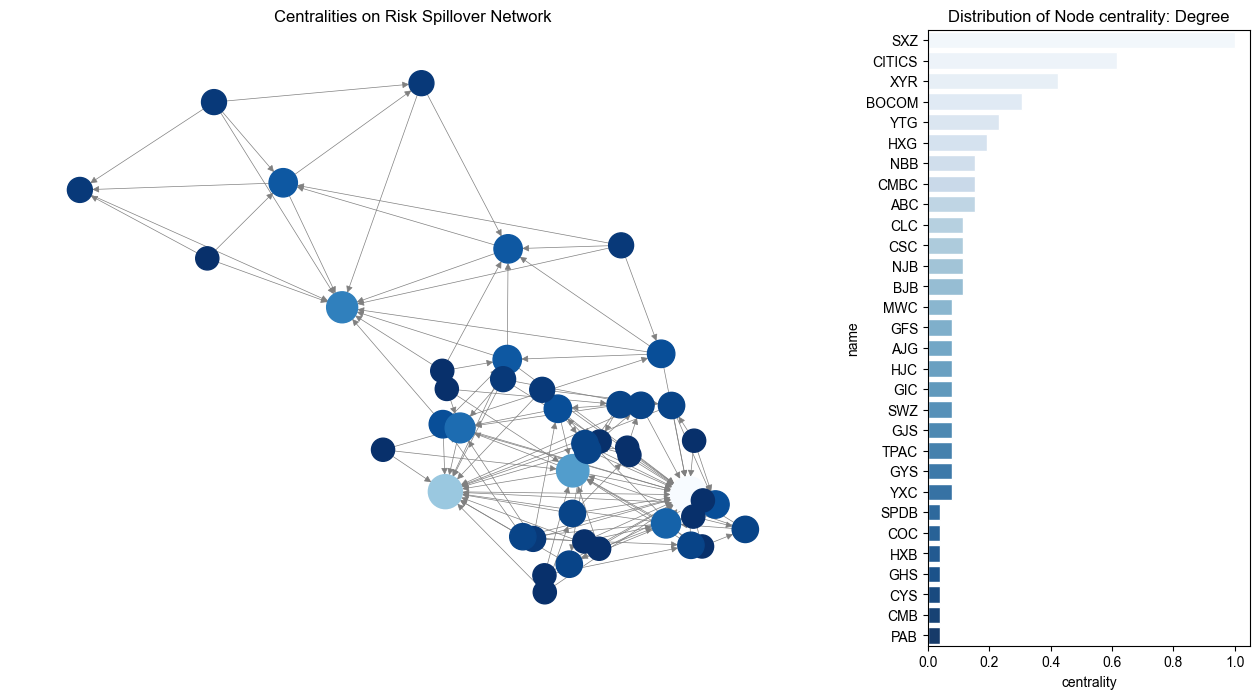

In [37]:
c_degree = nx.degree_centrality(pmfg)
max_centrality = max(c_degree,key=lambda x:c_degree[x])
print('最大中心性：',max_centrality,c_degree[max_centrality])
pos = nx.kamada_kawai_layout(pmfg)
plot_network_centrality(pmfg, centrality=c_degree, title='Degree',pos=pos)

In [38]:
# 加载英文简称与中文对应表
file_path = '../data/金融机构对照.xlsx'  # 请将此路径替换为您的实际路径
financial_mapping = pd.read_excel(file_path, header=None, names=["Code", "Name"])

# 清理 Code 列，确保与 Louvain 社群划分字典的键匹配
financial_mapping["Code"] = financial_mapping["Code"].str.strip()  # 去掉多余的空格
financial_mapping["Code"] = financial_mapping["Code"].str.upper()  # 转换为大写

# 计算度中心性
c_degree = nx.degree_centrality(pmfg)

# 将中心性结果存储为DataFrame
centrality_data = pd.DataFrame({
    "Code": list(c_degree.keys()),
    "Degree Centrality": list(c_degree.values())
})

# 添加中文名称
centrality_data = centrality_data.merge(financial_mapping, on="Code", how="left")

# 保存为Excel文件
output_file = '../result/centrality/Degree_Centrality.xlsx'  # 输出文件路径
centrality_data.to_excel(output_file, index=False)

print(f"度中心性结果已保存为 {output_file}")

度中心性结果已保存为 ../result/centrality/Degree_Centrality.xlsx


最大中心性： NJB 72


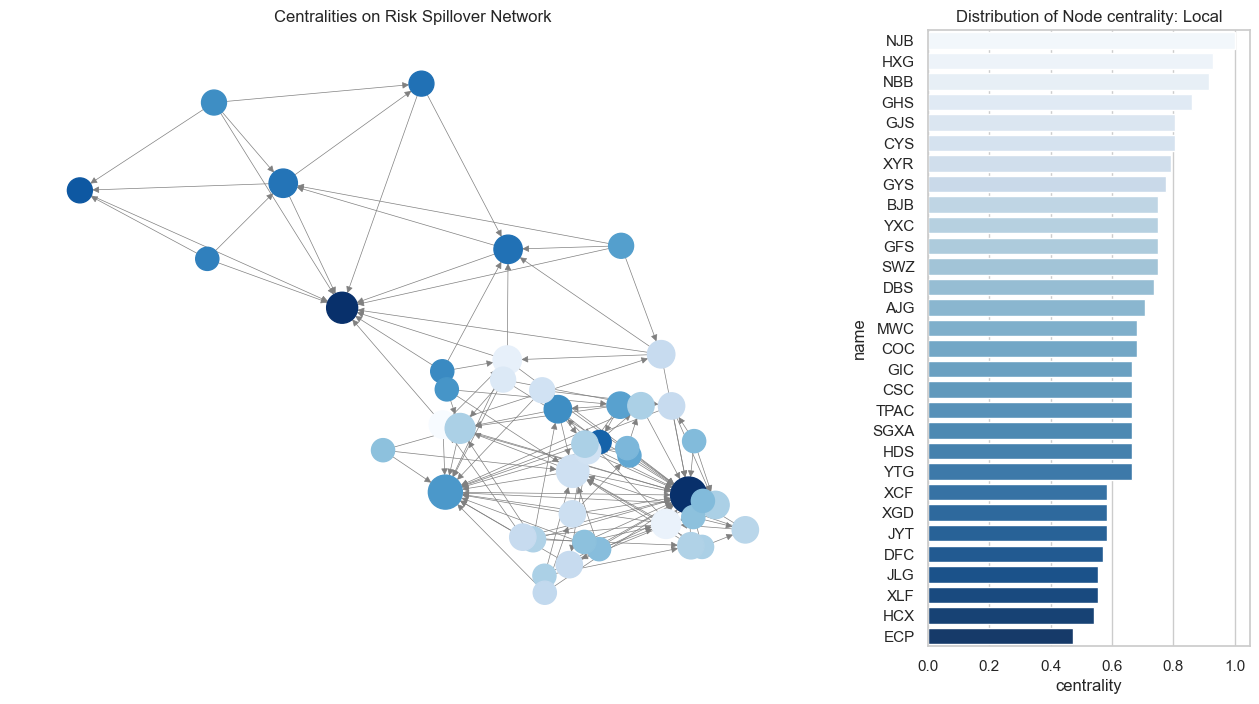

In [39]:
def LocalRank(pmfg):
    LR = {}
    N = pmfg.degree  # a dict
    for i in pmfg.nodes():
        lr = 0
        neigh_i = pmfg.neighbors(i)
        for j in neigh_i:
            lr += N[j]
        LR[i] = lr  
    return LR

c_local = LocalRank(pmfg)
max_centrality = max(c_local,key=lambda x:c_local[x])
print('最大中心性：',max_centrality,c_local[max_centrality])
plot_network_centrality(pmfg, centrality=c_local, title='Local',pos=pos)

<div style="color:white;display:fill;border-radius:8px;
            background-color:#d3d3d3;font-size:150%;
            font-family:Nexa;letter-spacing:0.5px">
    <p style="padding: 8px;color:white;"><b>2.集聚系数中心性</b></p>
</div>

最大中心性： ECP 0.5


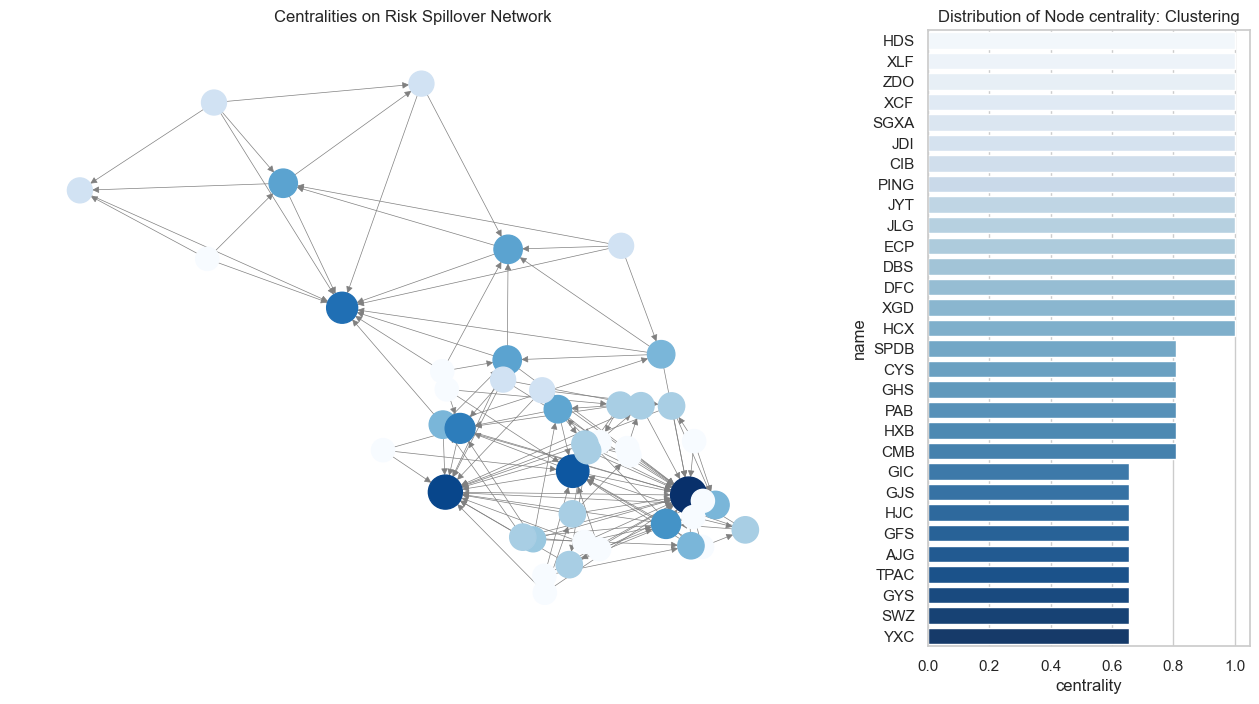

In [40]:
c_clustering = nx.clustering(pmfg)
max_centrality = max(c_clustering,key=lambda x:c_clustering[x])
print('最大中心性：',max_centrality,c_clustering[max_centrality])
plot_network_centrality(pmfg, centrality=c_clustering, title='Clustering',pos=pos)

<div style="color:white;display:fill;border-radius:8px;
            background-color:#d3d3d3;font-size:150%;
            font-family:Nexa;letter-spacing:0.5px">
    <p style="padding: 8px;color:white;"><b>3.结构洞</b></p>
</div>

In [41]:
import pandas as pd
import networkx as nx

def calculate_and_save_centrality(pmfg, centrality_function, financial_mapping_path, output_file_path, centrality_name="Centrality"):
    """
    计算指定中心性指标并保存结果为Excel文件，同时包含英文简称和中文对应。
    
    :param pmfg: 网络图（Graph 对象）
    :param centrality_function: 中心性计算函数，如 nx.degree_centrality、nx.betweenness_centrality 等
    :param financial_mapping_path: 金融机构英文简称与中文名称对应表的路径
    :param output_file_path: 结果保存路径（Excel 文件）
    :param centrality_name: 中心性名称，保存时作为列名
    """
    # 加载金融机构对应表
    financial_mapping = pd.read_excel(financial_mapping_path, header=None, names=["Code", "Name"])
    
    # 清理 Code 列，确保与中心性计算结果的键匹配
    financial_mapping["Code"] = financial_mapping["Code"].str.strip()  # 去掉多余的空格
    financial_mapping["Code"] = financial_mapping["Code"].str.upper()  # 转换为大写

    # 计算中心性
    centrality_result = centrality_function(pmfg)

    # 将中心性结果存储为DataFrame
    centrality_data = pd.DataFrame({
        "Code": list(centrality_result.keys()),
        centrality_name: list(centrality_result.values())
    })

    # 添加中文名称
    centrality_data = centrality_data.merge(financial_mapping, on="Code", how="left")

    # 保存结果为Excel文件
    centrality_data.to_excel(output_file_path, index=False)

    print(f"{centrality_name} 结果已保存为 {output_file_path}")


In [42]:
# 文件路径
financial_mapping_path = '../data/金融机构对照.xlsx'
output_file_path = '../result/centrality/Constraint.xlsx'

# 调用函数计算并保存结构洞约束
calculate_and_save_centrality(
    pmfg=pmfg,
    centrality_function=nx.algorithms.structuralholes.constraint,
    financial_mapping_path=financial_mapping_path,
    output_file_path=output_file_path,
    centrality_name="Constraint"
)

Constraint 结果已保存为 ../result/centrality/Constraint.xlsx


In [43]:
# 文件路径
financial_mapping_path = '../data/金融机构对照.xlsx'
output_file_path = '../result/centrality/clustering.xlsx'

# 调用函数计算并保存特征向量中心性
calculate_and_save_centrality(
    pmfg=pmfg,
    centrality_function=nx.clustering,
    financial_mapping_path=financial_mapping_path,
    output_file_path=output_file_path,
    centrality_name="clustering"
)

clustering 结果已保存为 ../result/centrality/clustering.xlsx


最大结构洞： CIB 0.584474147785836


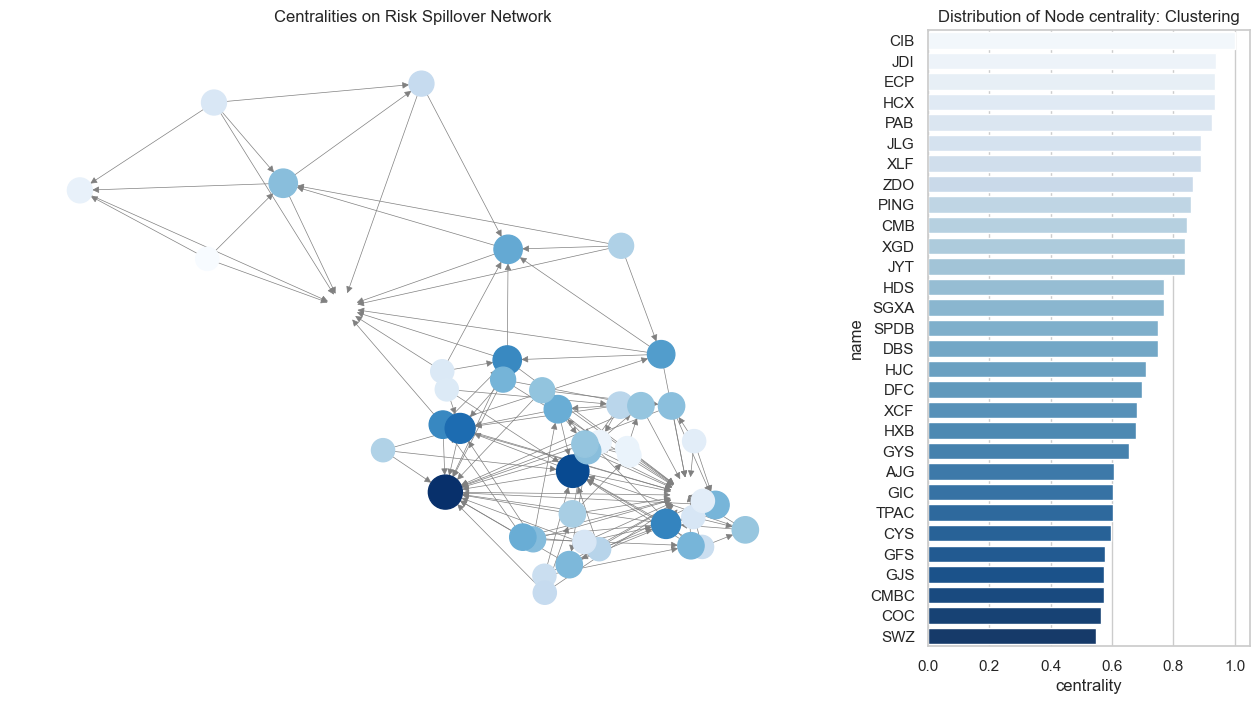

In [44]:
constraint = nx.algorithms.structuralholes.constraint(pmfg)
max_centrality = max(constraint,key=lambda x:constraint[x])
print('最大结构洞：',max_centrality,constraint[max_centrality])
plot_network_centrality(pmfg, centrality=constraint, title='Clustering',pos=pos)

<div style="color:white;display:fill;border-radius:8px;
            background-color:#d3d3d3;font-size:150%;
            font-family:Nexa;letter-spacing:0.5px">
    <p style="padding: 8px;color:white;"><b>4.信息熵</b></p>
</div>

最大信息熵： NJB 2.296604490501439


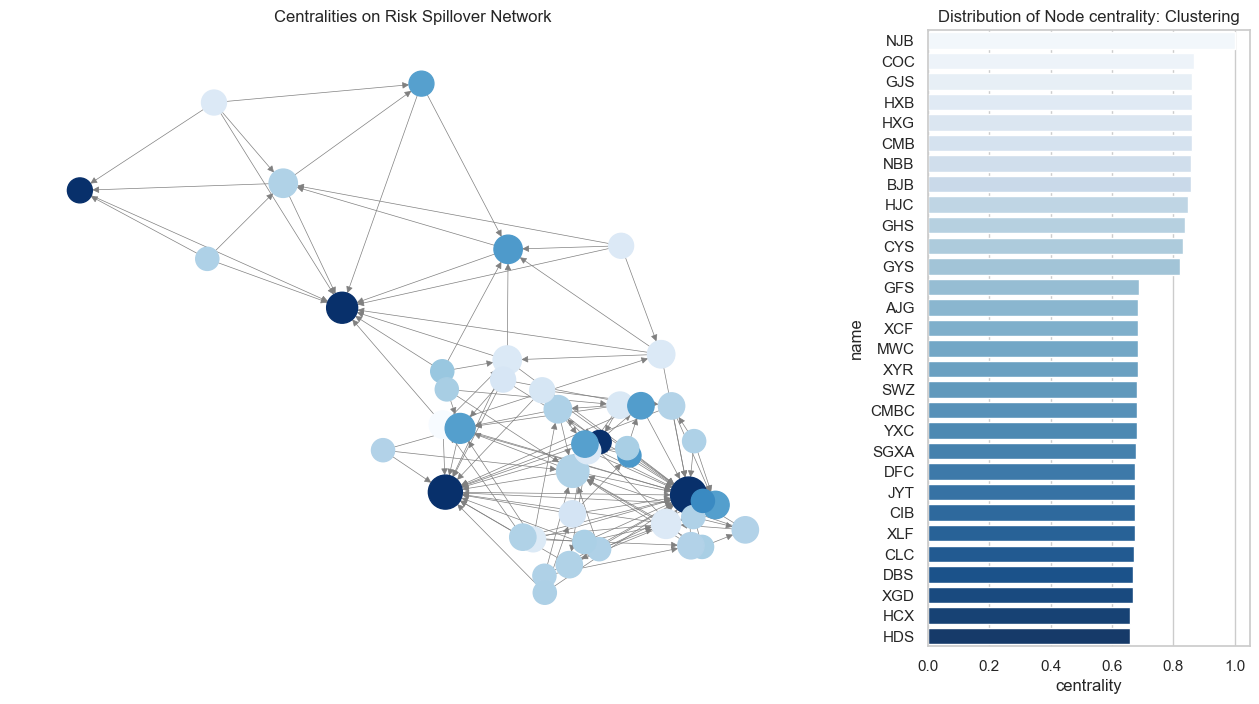

In [45]:
from scipy.stats import entropy
def calculate_entropy(graph):
    entropy_dict = {}
    for node in graph.nodes():
        neighbors = list(graph.neighbors(node))
        if not neighbors:
            entropy_dict[node] = 0
            continue

        total_weight = sum(graph[node][nbr]['weight'] for nbr in neighbors)
        probs = [graph[node][nbr]['weight'] / total_weight for nbr in neighbors]
        entropy_dict[node] = entropy(probs, base=2)  # 使用 log base 2
    return entropy_dict

entropy_values = calculate_entropy(pmfg)
max_centrality = max(entropy_values,key=lambda x:entropy_values[x])
print('最大信息熵：',max_centrality,entropy_values[max_centrality])
plot_network_centrality(pmfg, centrality=entropy_values, title='Clustering',pos=pos)

In [46]:
def calculate_and_save_custom_centrality(pmfg, centrality_function, financial_mapping_path, output_file_path, centrality_name="Custom Centrality"):
    """
    计算自定义中心性指标（如信息熵）并保存结果为Excel文件，同时包含英文简称和中文对应。
    
    :param pmfg: 网络图（Graph 对象）
    :param centrality_function: 自定义中心性计算函数，输入为图，输出为中心性字典
    :param financial_mapping_path: 金融机构英文简称与中文名称对应表的路径
    :param output_file_path: 结果保存路径（Excel 文件）
    :param centrality_name: 中心性名称，保存时作为列名
    """
    # 加载金融机构对应表
    financial_mapping = pd.read_excel(financial_mapping_path, header=None, names=["Code", "Name"])
    
    # 清理 Code 列，确保与中心性计算结果的键匹配
    financial_mapping["Code"] = financial_mapping["Code"].str.strip()  # 去掉多余的空格
    financial_mapping["Code"] = financial_mapping["Code"].str.upper()  # 转换为大写

    # 计算中心性
    centrality_result = centrality_function(pmfg)

    # 将中心性结果存储为DataFrame
    centrality_data = pd.DataFrame({
        "Code": list(centrality_result.keys()),
        centrality_name: list(centrality_result.values())
    })

    # 添加中文名称
    centrality_data = centrality_data.merge(financial_mapping, on="Code", how="left")

    # 保存结果为Excel文件
    centrality_data.to_excel(output_file_path, index=False)

    print(f"{centrality_name} 结果已保存为 {output_file_path}")


# 文件路径
financial_mapping_path = '../data/金融机构对照.xlsx'
output_file_path = '../result/centrality/Entropy_Centrality.xlsx'

# 调用函数计算并保存信息熵
calculate_and_save_custom_centrality(
    pmfg=pmfg,
    centrality_function=calculate_entropy,
    financial_mapping_path=financial_mapping_path,
    output_file_path=output_file_path,
    centrality_name="Entropy"
)

Entropy 结果已保存为 ../result/centrality/Entropy_Centrality.xlsx


## （二）基于网络全局属性
<div style="color:white;display:fill;border-radius:8px;
            background-color:#d3d3d3;font-size:150%;
            font-family:Nexa;letter-spacing:0.5px">
    <p style="padding: 8px;color:white;"><b>5.接近中心性</b></p>
</div>

最大中心性： SXZ 0.6914141414141414


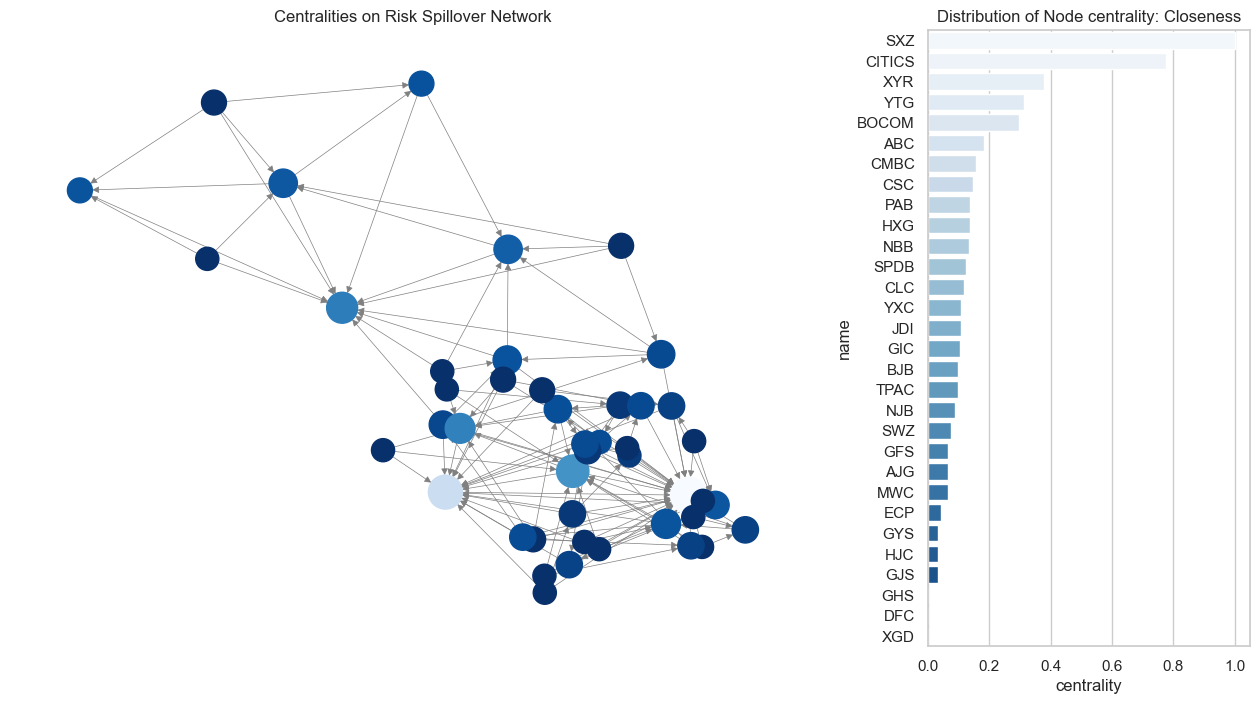

In [47]:
c_closeness = nx.closeness_centrality(pmfg)
max_centrality = max(c_closeness,key=lambda x:c_closeness[x])
print('最大中心性：',max_centrality,c_closeness[max_centrality])
plot_network_centrality(pmfg, centrality=c_closeness, title='Closeness',pos=pos)

In [48]:
# 文件路径
output_file_path = '../result/centrality/closeness_centrality.xlsx'

# 调用函数计算并保存介数中心性
calculate_and_save_centrality(
    pmfg=pmfg,
    centrality_function=nx.closeness_centrality,
    financial_mapping_path=financial_mapping_path,
    output_file_path=output_file_path,
    centrality_name="closeness_centrality"
)

closeness_centrality 结果已保存为 ../result/centrality/closeness_centrality.xlsx


<div style="color:white;display:fill;border-radius:8px;
            background-color:#d3d3d3;font-size:150%;
            font-family:Nexa;letter-spacing:0.5px">
    <p style="padding: 8px;color:white;"><b>6.介数中心性</b></p>
</div>

最大中心性： NJB 0.025898520084566598


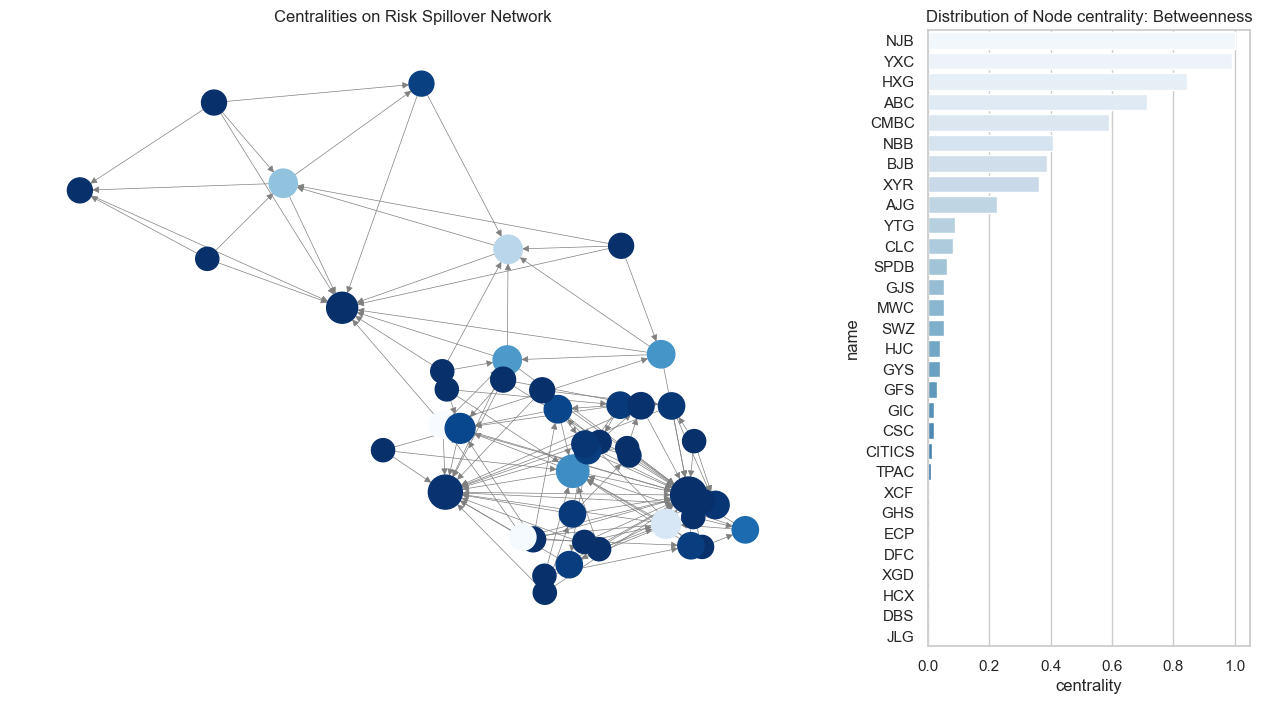

In [49]:
c_between = nx.betweenness_centrality(pmfg)
max_centrality = max(c_between,key=lambda x:c_between[x])
print('最大中心性：',max_centrality,c_between[max_centrality])
plot_network_centrality(pmfg, centrality=c_between, title='Betweenness',pos=pos)

In [50]:
# 文件路径
output_file_path = '../result/centrality/Betweenness_Centrality.xlsx'

# 调用函数计算并保存介数中心性
calculate_and_save_centrality(
    pmfg=pmfg,
    centrality_function=nx.betweenness_centrality,
    financial_mapping_path=financial_mapping_path,
    output_file_path=output_file_path,
    centrality_name="Betweenness Centrality"
)

Betweenness Centrality 结果已保存为 ../result/centrality/Betweenness_Centrality.xlsx


<div style="color:white;display:fill;border-radius:8px;
            background-color:#d3d3d3;font-size:150%;
            font-family:Nexa;letter-spacing:0.5px">
    <p style="padding: 8px;color:white;"><b>7.特征向量中心性</b></p>
</div>

最大中心性： BOCOM 0.8944259752793532


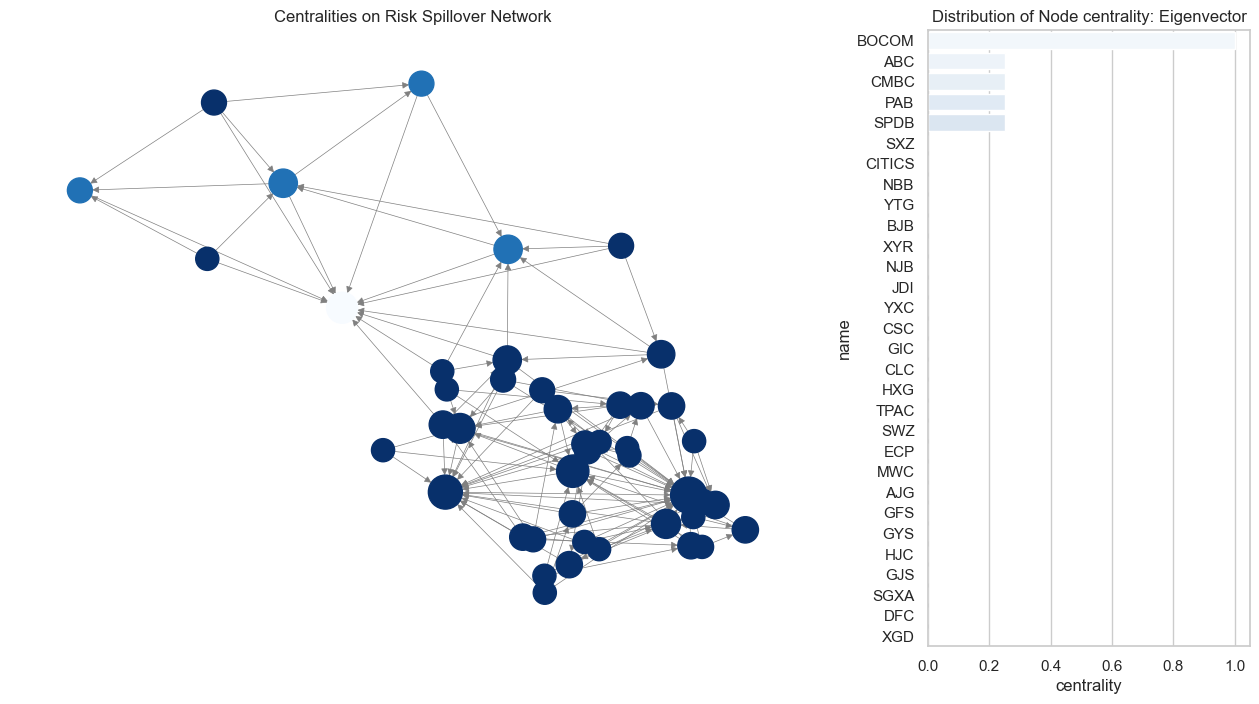

In [51]:
c_eigen = nx.eigenvector_centrality(pmfg,max_iter=1000)
max_centrality = max(c_eigen,key=lambda x:c_eigen[x])
print('最大中心性：',max_centrality,c_eigen[max_centrality])
plot_network_centrality(pmfg, centrality=c_eigen, title='Eigenvector',pos=pos)

In [52]:
def calculate_and_save_centrality(pmfg, centrality_function, financial_mapping_path, output_file_path, centrality_name="Centrality"):
    # 加载金融机构对应表
    financial_mapping = pd.read_excel(financial_mapping_path, header=None, names=["Code", "Name"])
    
    # 清理 Code 列，确保与中心性计算结果的键匹配
    financial_mapping["Code"] = financial_mapping["Code"].str.strip()  # 去掉多余的空格
    financial_mapping["Code"] = financial_mapping["Code"].str.upper()  # 转换为大写

    # 计算中心性
    centrality_result = centrality_function(pmfg)

    # 将中心性结果存储为DataFrame
    centrality_data = pd.DataFrame({
        "Code": list(centrality_result.keys()),
        centrality_name: list(centrality_result.values())
    })

    # 添加中文名称
    centrality_data = centrality_data.merge(financial_mapping, on="Code", how="left")

    # 保存结果为Excel文件
    centrality_data.to_excel(output_file_path, index=False)

    print(f"{centrality_name} 结果已保存为 {output_file_path}")

# 文件路径
financial_mapping_path = '../data/金融机构对照.xlsx'
output_file_path = '../result/centrality/Eigenvector_Centrality.xlsx'

# 调用函数计算并保存特征向量中心性
calculate_and_save_centrality(
    pmfg=pmfg,
    centrality_function=lambda graph: nx.eigenvector_centrality(graph, max_iter=1000),
    financial_mapping_path=financial_mapping_path,
    output_file_path=output_file_path,
    centrality_name="Eigenvector Centrality"
)


Eigenvector Centrality 结果已保存为 ../result/centrality/Eigenvector_Centrality.xlsx


### （三）基于网络位置属性
<div style="color:white;display:fill;border-radius:8px;
            background-color:#d3d3d3;font-size:150%;
            font-family:Nexa;letter-spacing:0.5px">
    <p style="padding: 8px;color:white;"><b>8.k-core中心性</b></p>
</div>

最大中心性： XYR 4


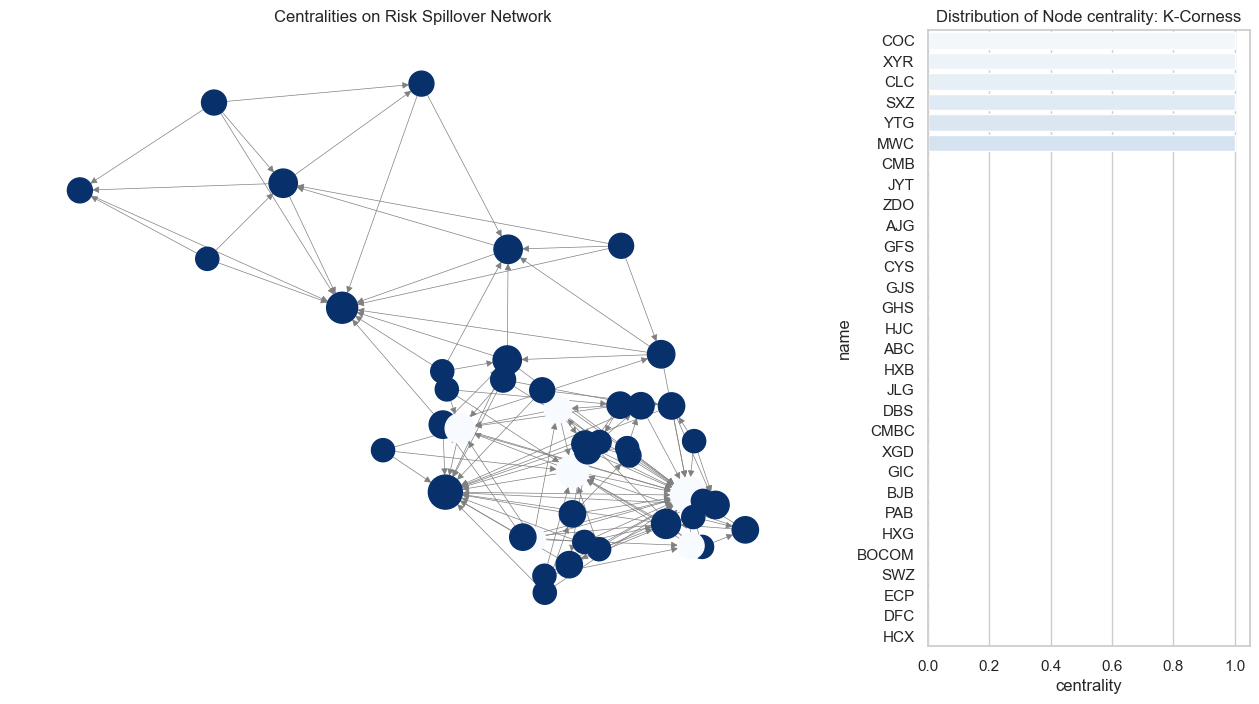

In [53]:
c_kcore = nx.core_number(pmfg)
max_centrality = max(c_kcore,key=lambda x:c_kcore[x])
print('最大中心性：',max_centrality,c_kcore[max_centrality])
plot_network_centrality(pmfg, centrality=c_kcore, title='K-Corness',pos=pos)

### （四）基于随机游走
<div style="color:white;display:fill;border-radius:8px;
            background-color:#d3d3d3;font-size:150%;
            font-family:Nexa;letter-spacing:0.5px">
    <p style="padding: 8px;color:white;"><b>9.Pagerank</b></p>
</div>

最大中心性： SXZ 0.22304469055156717


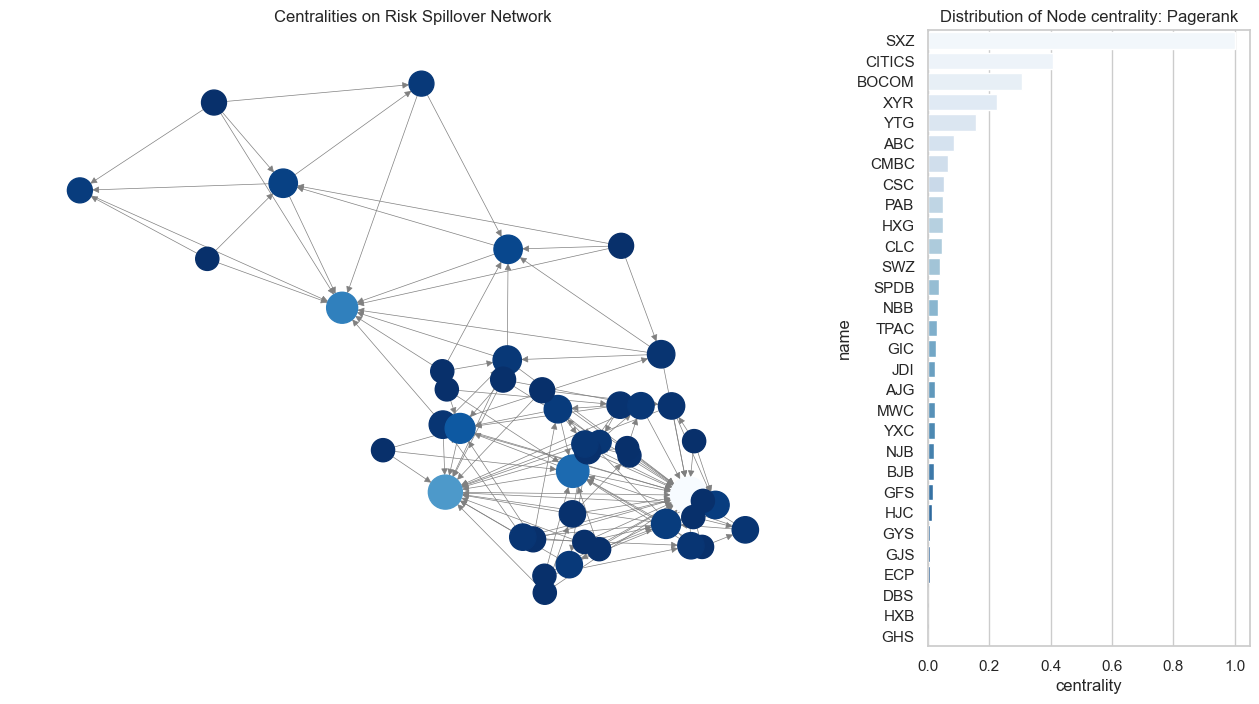

In [54]:
c_pr = nx.pagerank(pmfg)
max_centrality = max(c_pr,key=lambda x:c_pr[x])
print('最大中心性：',max_centrality,c_pr[max_centrality])
plot_network_centrality(pmfg, centrality=c_pr, title='Pagerank',pos=pos)

In [55]:
# 文件路径
financial_mapping_path = '../data/金融机构对照.xlsx'
output_file_path = '../result/centrality/pagerank.xlsx'

# 调用函数计算并保存特征向量中心性
calculate_and_save_centrality(
    pmfg=pmfg,
    centrality_function=nx.pagerank,
    financial_mapping_path=financial_mapping_path,
    output_file_path=output_file_path,
    centrality_name="pagerank"
)

pagerank 结果已保存为 ../result/centrality/pagerank.xlsx


### （五）其他
<div style="color:white;display:fill;border-radius:8px;
            background-color:#d3d3d3;font-size:150%;
            font-family:Nexa;letter-spacing:0.5px">
    <p style="padding: 8px;color:white;"><b>10.Voterank</b></p>
</div>

In [56]:
c_vote = nx.voterank(pmfg)
c_vote

['NJB',
 'HJC',
 'CMB',
 'GYS',
 'COC',
 'HXB',
 'GJS',
 'XLF',
 'JYT',
 'HXG',
 'PING',
 'CYS',
 'JLG',
 'CMBC',
 'CLC',
 'HCX',
 'HDS',
 'SGXA',
 'XGD',
 'BJB',
 'ECP',
 'CIB',
 'SWZ',
 'GHS']